# 1. Problem Statement

## Problem Definition

The objective of this project is to apply the DBSCAN (Density-Based Spatial 
Clustering of Applications with Noise) algorithm for clustering data points 
based on density.

DBSCAN groups closely packed data points into clusters and identifies 
outliers/noise points that do not belong to any cluster.

## Dataset Used

Dataset: Mall Customers Dataset

The dataset contains customer details:

- Genre
- Age
- Annual Income (k$)
- Spending Score (1-100)

The main objective is to segment customers based on their Annual Income 
and Spending Score using DBSCAN clustering.

In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

In [3]:
# Load dataset

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


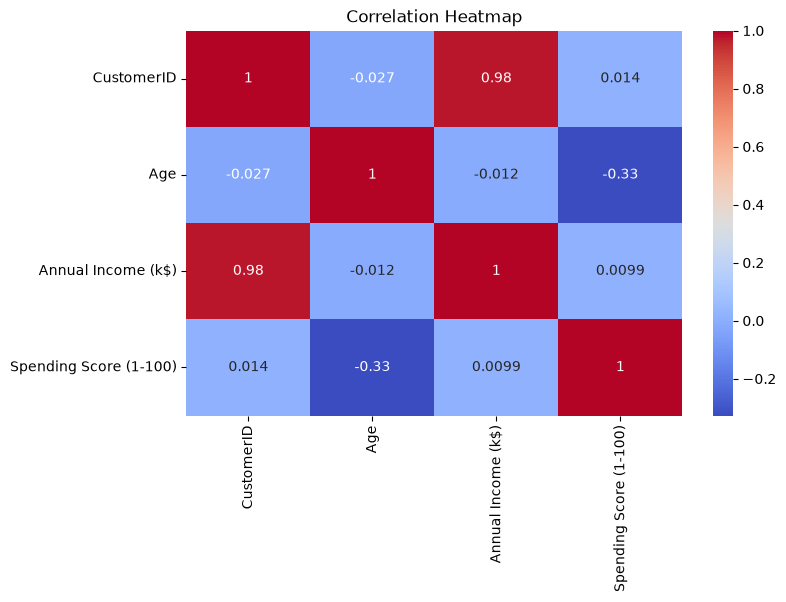

In [8]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

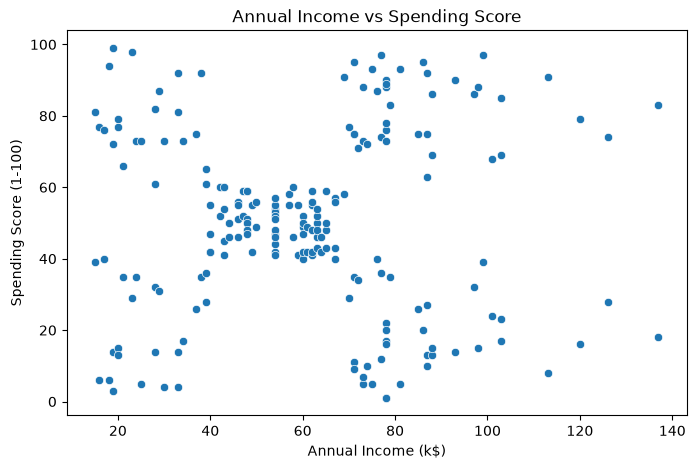

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")

plt.show()

In [10]:
df.fillna(
    df.mean(numeric_only=True),
    inplace=True
)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
df['Genre'] = df['Genre'].map({
    'Male':0,
    'Female':1
})

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [12]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [14]:
dbscan_model = DBSCAN(
    eps=0.5,
    min_samples=5
)

In [15]:
dbscan_labels = dbscan_model.fit_predict(
    X_scaled
)

dbscan_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0, -1, -1,  1, -1, -1, -1, -1, -1, -1])

In [16]:
# Remove noise points (-1)

mask = dbscan_labels != -1


if len(set(dbscan_labels[mask])) > 1:

    score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    print(
        "Silhouette Score:",
        score
    )

else:
    print("Not enough clusters for silhouette score")

Silhouette Score: 0.3875583892728279


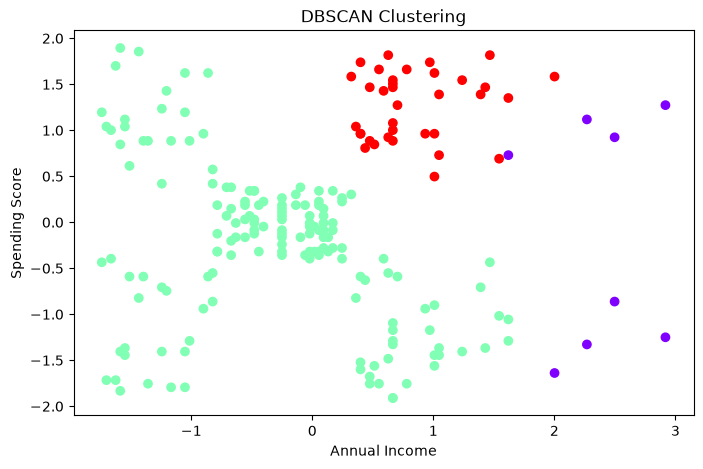

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_scaled.iloc[:,0],
    X_scaled.iloc[:,1],
    c=dbscan_labels,
    cmap="rainbow"
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("DBSCAN Clustering")

plt.show()

In [18]:
eps_values = [0.2,0.3,0.4,0.5,0.6,0.7,0.8]


for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    clusters = set(labels)

    if len(clusters) > 2 and -1 in clusters:

        mask = labels != -1

        score = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        print(
            "EPS:",
            eps,
            "Silhouette Score:",
            score
        )

EPS: 0.2 Silhouette Score: 0.5856126991466907
EPS: 0.3 Silhouette Score: 0.5243276105881419
EPS: 0.4 Silhouette Score: 0.4780592455223124
EPS: 0.5 Silhouette Score: 0.3875583892728279


# 11. Conclusion

In this project, DBSCAN clustering was applied to the Mall Customers dataset.

The algorithm grouped customers based on Annual Income and Spending Score.

The model was evaluated using:

- Silhouette Score
- Cluster Visualization

DBSCAN is useful because it can detect irregularly shaped clusters and 
identify noise or outlier data points.

Thus, DBSCAN is an effective unsupervised learning algorithm for discovering 
hidden patterns in datasets.